In [1]:
#Policy Evaluation Challenge
import numpy as np

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

def in_place_policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    V = np.zeros(env.n_states())
    converged_iter = max_iter
    for iteration in range(max_iter):
        delta = 0.0
        for s in range(env.n_states()):
            v_old = V[s]
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[ns]))
            V[s] = v
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta:
            converged_iter = iteration + 1
            break
    return V, converged_iter

env = GridWorld()
uniform_policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
V_inplace, iters = in_place_policy_evaluation(env, uniform_policy)
print(iters)
print(V_inplace.reshape(5,5))


60
[[-5.27622018 -5.18079181 -5.1219458  -4.99423414 -4.7090093 ]
 [-5.18079181 -5.13638292 -4.9937193  -4.70388372 -4.21000813]
 [-5.1219458  -4.9937193  -4.75166763 -4.40358911 -2.73758142]
 [-4.99423414 -4.70388372 -4.40358911 -1.93610607  0.69428387]
 [-4.7090093  -4.21000813 -2.73758142  0.69428387  5.29367051]]


In [2]:
# Policy Iteration Challenge
import numpy as np

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

def modified_policy_eval(env, policy, V, k, gamma=0.99):
    for _ in range(k):
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v
        V = V_new
    return V

def policy_improvement(env, V, gamma=0.99):
    policy = np.zeros((env.n_states(), env.n_actions()))
    for s in range(env.n_states()):
        Q_s = np.array([sum(p*(r + (0 if d else gamma*V[ns]))
                        for p,ns,r,d in env.transitions(s,a))
                        for a in range(env.n_actions())])
        best_actions = np.where(Q_s == Q_s.max())[0]
        policy[s, best_actions] = 1.0 / len(best_actions)
    return policy

def modified_policy_iteration(env, k=5, gamma=0.99):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    V = np.zeros(env.n_states())
    while True:
        V = modified_policy_eval(env, policy, V, k, gamma)
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            return policy, V
        policy = new_policy

env = GridWorld()
opt_policy, opt_V = modified_policy_iteration(env, k=5)
print(opt_policy.argmax(axis=1).reshape(5,5))


[[1 3 1 3 1]
 [1 1 1 1 1]
 [1 3 1 3 1]
 [1 1 1 1 1]
 [3 3 3 3 1]]


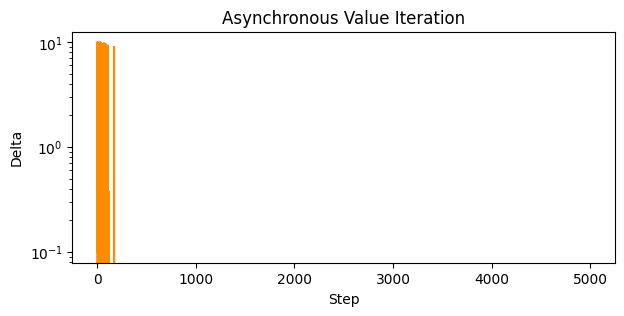

In [3]:
# Value Iteration Challenge
import numpy as np
import matplotlib.pyplot as plt

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

def async_value_iteration(env, gamma=0.99, max_steps=5000):
    V = np.zeros(env.n_states())
    errors = []
    np.random.seed(42)
    for step in range(max_steps):
        s = np.random.randint(env.n_states())
        v_old = V[s]
        Q_s = [sum(p*(r + (0 if d else gamma*V[ns])) for p,ns,r,d in env.transitions(s,a)) for a in range(env.n_actions())]
        V[s] = max(Q_s)
        errors.append(abs(V[s] - v_old))
    return V, errors

env = GridWorld()
V_async, errors = async_value_iteration(env)
plt.figure(figsize=(7,3))
plt.plot(errors, color='darkorange')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Delta')
plt.title('Asynchronous Value Iteration')
plt.show()


In [4]:
#Solving FrozenLake with Dynamic Programming Challenge
import gymnasium as gym
import numpy as np

env = gym.make('FrozenLake-v1', is_slippery=False)
np.random.seed(42)

def first_visit_mc_eval(env, policy, n_episodes=5000, gamma=0.99):
    n_s = env.observation_space.n
    V = np.zeros(n_s)
    returns = {s: [] for s in range(n_s)}
    for _ in range(n_episodes):
        s, _ = env.reset()
        episode = []
        done = False
        while not done:
            a = policy[s]
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            episode.append((s, r))
            s = ns
        G = 0
        visited = set()
        for s, r in reversed(episode):
            G = r + gamma * G
            if s not in visited:
                visited.add(s)
                returns[s].append(G)
    for s in range(n_s):
        if returns[s]:
            V[s] = np.mean(returns[s])
    return V

dummy_policy = np.ones(env.observation_space.n, dtype=int) * 1
V_mc = first_visit_mc_eval(env, dummy_policy)
print(V_mc.reshape(4,4))


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [5]:
#Implement policy evaluation and verify convergence
import numpy as np

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

def policy_eval(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns])) for p,ns,r,d in env.transitions(s,a)) for a in range(env.n_actions()))
            V_new[s] = v; delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < theta: break
    return V

env = GridWorld()
uniform_policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
V_final = policy_eval(env, uniform_policy)
print(V_final.reshape(5,5))


[[-5.27621924 -5.18079076 -5.12194453 -4.99423288 -4.7090076 ]
 [-5.18079076 -5.13638175 -4.99371864 -4.7038826  -4.21000697]
 [-5.12194453 -4.99371864 -4.75166691 -4.40358862 -2.73758051]
 [-4.99423288 -4.7038826  -4.40358862 -1.93610552  0.69428427]
 [-4.7090076  -4.21000697 -2.73758051  0.69428427  5.29367077]]


In [6]:
# Implement policy iteration
import numpy as np

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

def policy_eval(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns])) for p,ns,r,d in env.transitions(s,a)) for a in range(env.n_actions()))
            V_new[s] = v; delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < theta: break
    return V

def policy_improvement(env, V, gamma=0.99):
    policy = np.zeros((env.n_states(), env.n_actions()))
    for s in range(env.n_states()):
        Q_s = np.array([sum(p*(r + (0 if d else gamma*V[ns])) for p,ns,r,d in env.transitions(s,a)) for a in range(env.n_actions())])
        best_actions = np.where(Q_s == Q_s.max())[0]
        policy[s, best_actions] = 1.0 / len(best_actions)
    return policy

def policy_iteration(env, gamma=0.99):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    while True:
        V = policy_eval(env, policy, gamma)
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            return policy, V
        policy = new_policy

env = GridWorld()
opt_policy, opt_V = policy_iteration(env)
print(opt_policy.argmax(axis=1).reshape(5,5))


[[1 3 1 3 1]
 [1 1 1 1 1]
 [1 3 1 3 1]
 [1 1 1 1 1]
 [3 3 3 3 1]]


In [7]:
#Implement value iteration
import numpy as np

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

def value_iteration(env, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            Q_s = [sum(p*(r + (0 if d else gamma*V[ns])) for p,ns,r,d in env.transitions(s,a)) for a in range(env.n_actions())]
            V_new[s] = max(Q_s)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        if delta < theta: break
    policy = np.zeros(env.n_states(), dtype=int)
    for s in range(env.n_states()):
        Q_s = [sum(p*(r + (0 if d else gamma*V[ns])) for p,ns,r,d in env.transitions(s,a)) for a in range(env.n_actions())]
        policy[s] = np.argmax(Q_s)
    return V, policy

env = GridWorld()
V_star, pi_star = value_iteration(env)
print(pi_star.reshape(5,5))


[[1 3 1 3 1]
 [1 1 1 1 1]
 [1 3 1 3 1]
 [1 1 1 1 1]
 [3 3 3 3 1]]


Win Rate: 100%


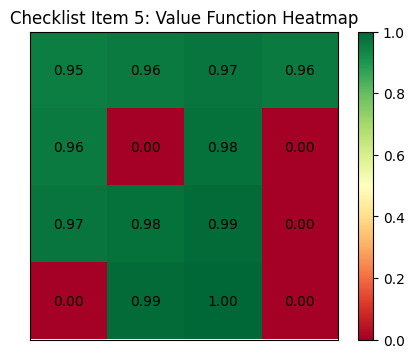

In [8]:
#Solve FrozenLake with 100% win rate and visualize value function
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys; subprocess.check_call([sys.executable,'-m','pip','install','gymnasium','-q']); import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make('FrozenLake-v1', is_slippery=False)
np.random.seed(42)

def value_iteration_gym(env_unwrapped, gamma=0.99, theta=1e-8):
    n_s = env_unwrapped.observation_space.n
    n_a = env_unwrapped.action_space.n
    V = np.zeros(n_s)
    while True:
        delta = 0
        V_new = np.zeros(n_s)
        for s in range(n_s):
            q_vals = [sum(p*(r + gamma*V[ns]*(not d)) for p,ns,r,d in env_unwrapped.unwrapped.P[s][a]) for a in range(n_a)]
            V_new[s] = max(q_vals)
            delta = max(delta, abs(V_new[s]-V[s]))
        V = V_new
        if delta < theta: break
    policy = np.zeros(n_s, dtype=int)
    for s in range(n_s):
        qs = [sum(p*(r+gamma*V[ns]*(not d)) for p,ns,r,d in env_unwrapped.unwrapped.P[s][a]) for a in range(n_a)]
        policy[s] = np.argmax(qs)
    return V, policy

V_ns, pi_ns = value_iteration_gym(env)

wins = 0
for _ in range(1000):
    s, _ = env.reset()
    for _ in range(200):
        s, r, term, trunc, _ = env.step(pi_ns[s])
        if term or trunc:
            if r == 1.0: wins += 1
            break
print(f"Win Rate: {wins / 1000:.0%}")

plt.figure(figsize=(5,4))
plt.imshow(V_ns.reshape(4,4), cmap='RdYlGn')
plt.colorbar()
for s in range(16):
    r, c = divmod(s, 4)
    plt.text(c, r, f'{V_ns[s]:.2f}', ha='center', va='center')
plt.xticks([]); plt.yticks([])
plt.title('Checklist Item 5: Value Function Heatmap')
plt.show()
